# Ejercicion de programación - Regresión Logistica

En este ejercicio se implementa regresion logistica.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
# se utiliza para el manejo de rutas y directorios.
import os
import pandas as pd
# Calculo cientifico y vectorial para python
import numpy as np

# Librerias para graficar
from matplotlib import pyplot

# Modulo de optimización de scipy
from scipy import optimize

# le dice a matplotlib que incruste gráficos en el cuaderno
%matplotlib inline

from matplotlib import pyplot as plt


In [7]:
# Celda 2
path = '/content/drive/MyDrive/mnist_train.csv'

# Al cargar, le decimos que la fila 0 es el encabezado.
# Así, Pandas entenderá que los datos reales empiezan en la fila 1.
data = pd.read_csv(path, header=0)

# Si el error persiste, usamos 'skiprows' para saltar la primera línea manualmente
# data = pd.read_csv(path, skiprows=1, header=None)

# Convertimos todo a float para asegurar que no haya texto oculto
data = data.apply(pd.to_numeric, errors='coerce')

# Borramos cualquier fila que haya quedado con errores (NaN)
data = data.dropna()

# La primera columna es la etiqueta
y = data.iloc[:, 0].values
# El resto son los 784 píxeles
X = data.iloc[:, 1:].values

# Ahora sí, dividimos entre 255.0. Como ya son números, no fallará.
X = X / 255.0

m, n = X.shape
X = np.concatenate([np.ones((m, 1)), X], axis=1)

print(f"Dataset cargado correctamente.")
print(f"Filas: {m}, Columnas: {n}")

Dataset cargado correctamente.
Filas: 60000, Columnas: 784


1.2 Implementacion
1.2.1 Fución Sigmoidea
La hipotesis para la regresión logistica se define como:

hθ(x)=g(θTx)

donde la función  g  is la función sigmoidea. La función sigmoidea se define como:

g(z)=11+e−z
.

Los resultados que debe generar la funcion sigmoidea para valores positivos amplios de x, deben ser cercanos a 1, mientras que para valores negativos grandes, la sigmoide debe generar valores cercanos 0. La evaluacion de sigmoid(0) debe dar un resultado exacto de 0.5. Esta funcion tambien debe poder trabajar con vectores y matrices

In [16]:
def sigmoid(z):
    # La función sigmoide convierte cualquier valor en una probabilidad entre 0 y 1
    return 1.0 / (1.0 + np.exp(-z))

def lrCostFunction(theta, X, y, lambda_):
    # Calcula el costo de usar theta como parámetro para la regresión logística
    m = y.size
    h = sigmoid(X.dot(theta))

    # Término de regularización (para evitar sobreajuste)
    temp = theta.copy()
    temp[0] = 0 # No regularizamos el intercepto

    # Fórmula del costo con regularización
    J = (1 / m) * np.sum(-y * np.log(h) - (1 - y) * np.log(1 - h)) + (lambda_ / (2 * m)) * np.sum(np.square(temp))

    # Cálculo del gradiente (la dirección hacia donde debe moverse theta)
    grad = (1 / m) * (h - y).dot(X) + (lambda_ / m) * temp

    return J, grad

In [13]:
def gradientDescent(X, y, theta, alpha, num_iters, lambda_):
    m = y.size
    J_history = []

    for i in range(num_iters):
        cost, grad = lrCostFunction(theta, X, y, lambda_)
        theta = theta - alpha * grad
        J_history.append(cost)

        if i % 100 == 0:
            print(f"Iteración {i}: Costo = {cost:.4f}")

    return theta, J_history

In [14]:
def oneVsAll(X, y, num_labels, alpha, num_iters, lambda_):
    m, n = X.shape
    all_theta = np.zeros((num_labels, n)) # Matriz para guardar los 10 juegos de pesos

    for i in range(num_labels):
        print(f"Entrenando clasificador para el número: {i}")
        initial_theta = np.zeros(n)
        # Creamos un vector y_binario donde es 1 si el número es i, y 0 si no lo es
        y_binario = (y == i).astype(int)

        theta, _ = gradientDescent(X, y_binario, initial_theta, alpha, num_iters, lambda_)
        all_theta[i, :] = theta

    return all_theta

# CONFIGURACIÓN DEL ENTRENAMIENTO
# Usamos pocos iteraciones al principio para probar (ej. 500)
# Alpha es la tasa de aprendizaje. Lambda ayuda a no memorizar los datos.
num_labels = 10
alpha = 0.1
num_iters = 500
lambda_ = 0.1

all_theta = oneVsAll(X, y, num_labels, alpha, num_iters, lambda_)

Entrenando clasificador para el número: 0
Iteración 0: Costo = 0.6931
Iteración 100: Costo = 0.0820
Iteración 200: Costo = 0.0647
Iteración 300: Costo = 0.0569
Iteración 400: Costo = 0.0523
Entrenando clasificador para el número: 1
Iteración 0: Costo = 0.6931
Iteración 100: Costo = 0.0733
Iteración 200: Costo = 0.0578
Iteración 300: Costo = 0.0514
Iteración 400: Costo = 0.0478
Entrenando clasificador para el número: 2
Iteración 0: Costo = 0.6931
Iteración 100: Costo = 0.1386
Iteración 200: Costo = 0.1153
Iteración 300: Costo = 0.1052
Iteración 400: Costo = 0.0994
Entrenando clasificador para el número: 3
Iteración 0: Costo = 0.6931
Iteración 100: Costo = 0.1489
Iteración 200: Costo = 0.1274
Iteración 300: Costo = 0.1181
Iteración 400: Costo = 0.1127
Entrenando clasificador para el número: 4
Iteración 0: Costo = 0.6931
Iteración 100: Costo = 0.1262
Iteración 200: Costo = 0.1020
Iteración 300: Costo = 0.0912
Iteración 400: Costo = 0.0848
Entrenando clasificador para el número: 5
Iteració

In [17]:
def predictOneVsAll(all_theta, X):
    # Calcula probabilidades para las 10 clases y elige la mayor
    probabilidades = sigmoid(X.dot(all_theta.T))
    return np.argmax(probabilidades, axis=1)

# Probamos con los primeros 10,000 datos
predicciones = predictOneVsAll(all_theta, X[:10000])
precision = np.mean(predicciones == y[:10000]) * 100

print(f"\nPrecisión del entrenamiento: {precision:.2f}%")


Precisión del entrenamiento: 89.11%


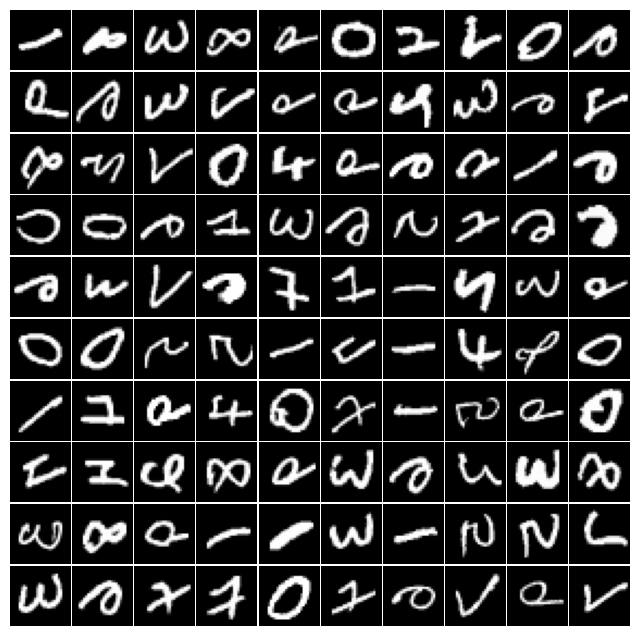

In [19]:
# Celda 8: Mostrar una cuadrícula de ejemplos
import matplotlib.pyplot as plt

def displayData(X, example_width=None):
    if example_width is None:
        example_width = int(np.round(np.sqrt(X.shape[1])))

    m, n = X.shape
    example_height = n // example_width

    display_rows = int(np.floor(np.sqrt(m)))
    display_cols = int(np.ceil(m / display_rows))

    fig, ax_array = plt.subplots(display_rows, display_cols, figsize=(8, 8))
    fig.subplots_adjust(wspace=0.025, hspace=0.025)

    ax_array = [ax_array] if m == 1 else ax_array.ravel()

    for i, ax in enumerate(ax_array):
        if i < m:
            # Mostramos el número (quitando el intercepto si existe)
            ax.imshow(X[i, 1:].reshape(example_height, example_width).T, cmap='gray')
            ax.axis('off')
    plt.show()

# Elegimos 100 números al azar para mostrar
rand_indices = np.random.choice(m, 100, replace=False)
sel = X[rand_indices, :]
displayData(sel)

In [20]:
# Celda 9: Prueba inicial del costo
# Creamos unos pesos 'theta' de prueba llenos de ceros
theta_prueba = np.zeros(X.shape[1])
# Probamos el costo para el número '0' con un lambda de 0.1
costo_inicial, _ = lrCostFunction(theta_prueba, X, (y == 0).astype(int), 0.1)

print(f"Costo inicial esperado para theta de ceros: 0.693")
print(f"Costo calculado: {costo_inicial:.3f}")

Costo inicial esperado para theta de ceros: 0.693
Costo calculado: 0.693


Iteración 0: Costo = 0.6931
Iteración 100: Costo = 0.1599
Iteración 200: Costo = 0.1305
Iteración 300: Costo = 0.1165


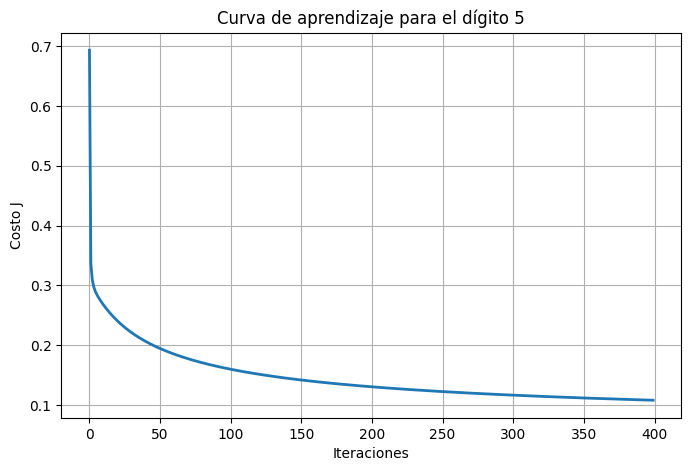

In [22]:
# Celda 10: Gráfico de convergencia para un número (ej. el número 5)
# Entrenamos solo el número 5 para ver su curva de aprendizaje
initial_theta = np.zeros(X.shape[1])
_, J_hist = gradientDescent(X[:5000], (y[:5000] == 5).astype(int), initial_theta, 0.1, 400, 0.1)

plt.figure(figsize=(8, 5))
plt.plot(J_hist, lw=2)
plt.title("Curva de aprendizaje para el dígito 5")
plt.xlabel("Iteraciones")
plt.ylabel("Costo J")
plt.grid(True)
plt.show()

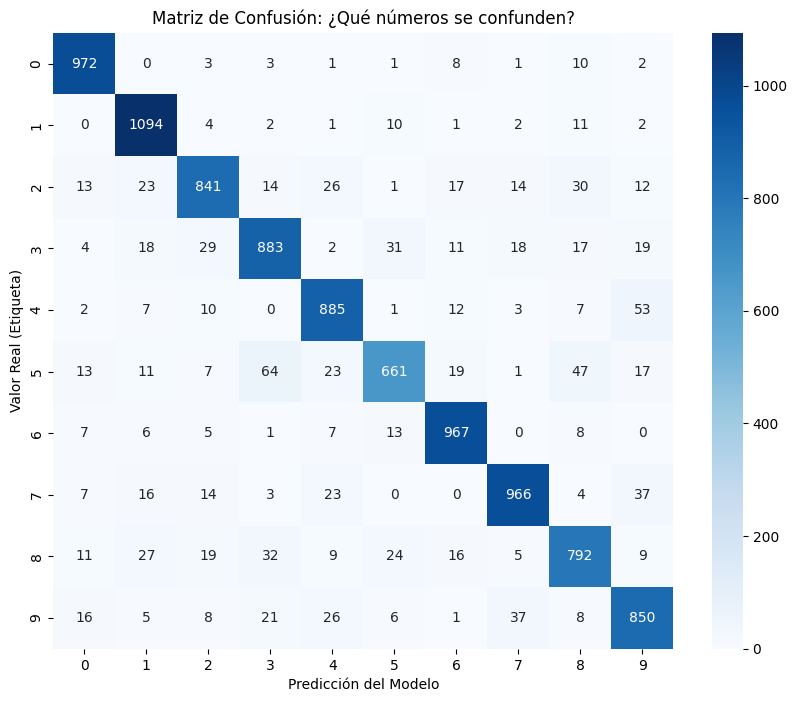

In [23]:
# Celda 11: Matriz de Confusión simplificada
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Obtenemos las predicciones finales
p_final = predictOneVsAll(all_theta, X[:10000])
cm = confusion_matrix(y[:10000], p_final)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicción del Modelo')
plt.ylabel('Valor Real (Etiqueta)')
plt.title('Matriz de Confusión: ¿Qué números se confunden?')
plt.show()

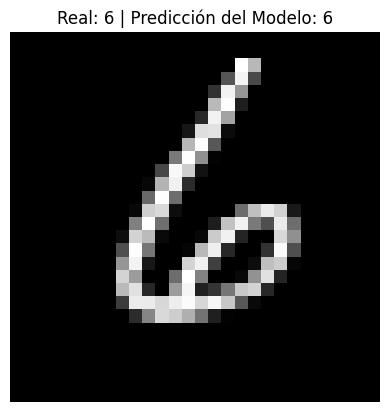

In [25]:
# Elegimos una fila al azar
idx = np.random.randint(0, 10000)

# Visualizamos (recordando que la columna 0 es el intercepto, no el píxel)
img = X[idx, 1:].reshape(28, 28)

plt.imshow(img, cmap='gray')
plt.title(f"Real: {y[idx]} | Predicción del Modelo: {predicciones[idx]}")
plt.axis('off')
plt.show()